### Manuscript figures

In [104]:
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path
from collections import defaultdict

import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, r2_score

from notebook_utils.embedding_helpers import load_encoded_latents, load_encoded_metadata
from notebook_utils.plotting_helpers import (
    load_point_regression_json,
    parity_cell_counts,
    plot_emergent_parity_row,
    plot_parity_size_legend,
    plot_trajectory_confusion_panels,
    print_emergent_parity_legend,
)

from simulation_encoder.loaders.loader_retrieval import load_loaders
from simulation_encoder.models.model_retrieval import load_models
from notebook_utils.figure_helpers import (
    collect_spatial_mse_train_test,
    plot_figure2b_spatial_mse_bars,
    collect_timepoint_parity_data,
    plot_figure2c_timepoint_parity,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [105]:
STUDY = "gastruloid" # "gastruloid" | "arcade"

CFG = {
    "gastruloid": {
        "study_dir": "architecture-gastruloid",
        "num_timepoints": 9,
        "dataset_name": "gastruloid_128",
        "figures_subdir": "gastruloid",
        "classification_suffix": "_trajectory_classification_results",
    },
    "arcade": {
        "study_dir": "architecture-ARCADE",
        "num_timepoints": 15,
        "dataset_name": "vascular_function_128",
        "figures_subdir": "ARCADE",
        "classification_suffix": "_trajectory_classification_results",
    },
}

image_dir = "data"
c = CFG[STUDY]
results_dir = f"results/{c['study_dir']}"
num_timepoints = c["num_timepoints"]
dataset_name = c["dataset_name"]

raw = load_models(
    results_dir,
    num_timepoints=num_timepoints,
    best_models_flag=True,
    map_location="cpu",
)
all_models = {
    k: v
    for k, v in sorted(raw.items())
}
loaders = load_loaders(results_dir, image_dir)
data_loaders = {
    name: {
        "train": ldr.get_dataloader("train"),
        "val": ldr.get_dataloader("val"),
        "test": ldr.get_dataloader("test"),
        "full": ldr,
    }
    for name, ldr in sorted(loaders.items())
}

print(STUDY, results_dir, list(all_models.keys()))


Loading model ae_small (1.98e+07 parameters)
Loading model cae_small (1.99e+07 parameters)
Loading model vit_small (2.03e+07 parameters)
Loading model neuralop_small (2.00e+07 parameters)
gastruloid results/architecture-gastruloid ['ae', 'cae', 'neuralop', 'vit']


### Figure 2

In [106]:
rows = collect_spatial_mse_train_test(
    results_dir,
    all_models,
    data_loaders,
    device="cpu"
)
for r in rows:
    print(
        f"{r['model']:12}  train(min)={r['train_mse']:.6f}  test={r['test_mse']:.6f}"
    )


Validation:   0%|                                                                           | 0/1845 [00:00<?, ?batch/s]/Users/jacobevarts/BagheriLab/simulation-encoder/.venv/lib/python3.11/site-packages/tltorch/factorized_tensors/factorized_tensors.py:66: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:351.)
  return self.__class__(self.tensor[indices])
/Users/jacobevarts/BagheriLab/simulation-encoder/.venv/lib/python3.11/site-packages/neuralop/layers/spectral_convolution.py:468: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x

ae            train(min)=0.010970  test=0.010906
cae           train(min)=0.010689  test=0.011158
neuralop      train(min)=0.010819  test=0.012844
vit           train(min)=0.011211  test=0.011176


array2_99
array2_99
array2_99
array2_99
array2_99
array2_99
array2_99
array2_99
array2_99
array2_8
array2_8
array2_8
array2_8
array2_8
array2_8
array2_8
array2_8
array2_8
array2_160
array2_160
array2_160
array2_160
array2_160
array2_160
array2_160
array2_160
array2_160
array1_358
array1_358
array1_358
array1_358
array1_358
array1_358
array1_358
array1_358
array1_358
array2_21
array2_21
array2_21
array2_21
array2_21
array2_21
array2_21
array2_21
array2_21
array2_398
array2_398
array2_398
array2_398
array2_398
array2_398
array2_398
array2_398
array2_398
array2_68
array2_68
array2_68
array2_68
array2_68
array2_68
array2_68
array2_68
array2_68
array2_274
array2_274
array2_274
array2_274
array2_274
array2_274
array2_274
array2_274
array2_274
array1_260
array1_260
array1_260
array1_260
array1_260
array1_260
array1_260
array1_260
array1_260
array2_377
array2_377
array2_377
array2_377
array2_377
array2_377
array2_377
array2_377
array2_377
array2_452
array2_452
array2_452
array2_452
array2_452


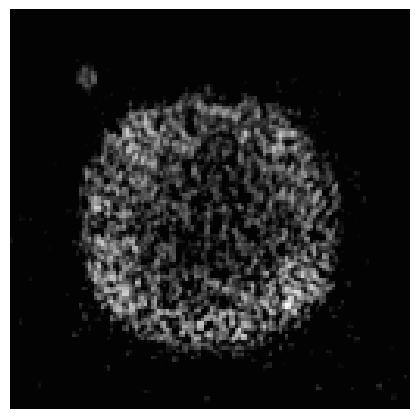

ae


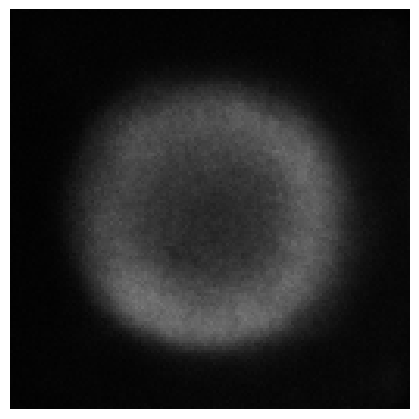

cae


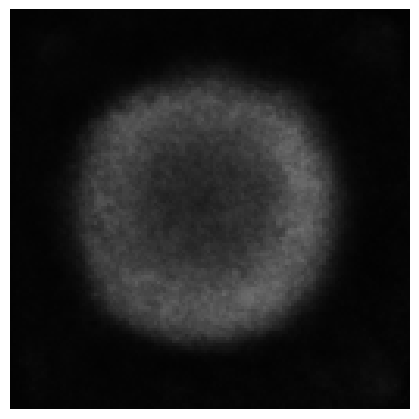

neuralop


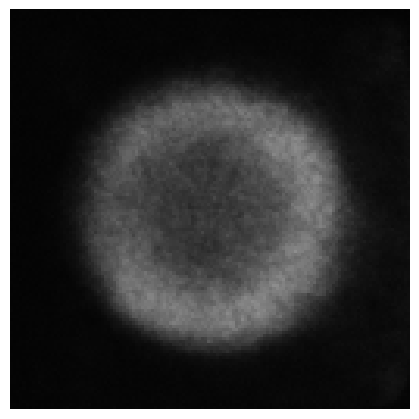

vit


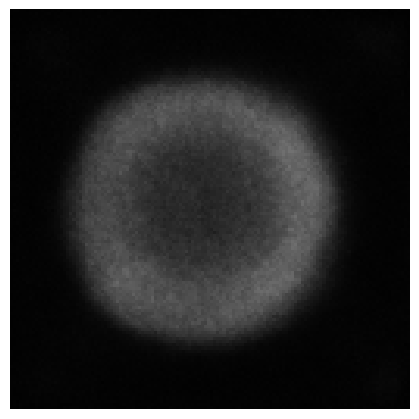

In [150]:
# Fig 2a
def _tensor_to_imshow(x: torch.Tensor) -> np.ndarray:
    """(B,C,H,W) or (C,H,W) -> array for imshow, channels last or 2D grayscale."""
    t = x.detach().float().cpu()
    if t.ndim == 4:
        t = t[0]
    t = torch.clamp(t, 0.0, 1.0)
    if t.shape[0] == 1:
        return t.squeeze(0).numpy()
    return t.permute(1, 2, 0).numpy()

def _safe_fn_fragment(s):
    t = "".join((c if c.isalnum() or c in "-_" else "_") for c in str(s)).strip("_")
    return t or "model"

if STUDY == "gastruloid":
    fig2a_sample_id = "array1_228"
else:
    fig2a_sample_id = "C_1"

if STUDY == "gastruloid":
    fig2a_timepoint = 1
else:
    fig2a_timepoint = 14

_test_ds = data_loaders[dataset_name]["test"].dataset
_matches = []
for _j, _row in enumerate(_test_ds.data):
    print(_row["sample_id"])
    if str(_row["sample_id"]) != str(fig2a_sample_id):
        continue
    if int(_row["timepoint"]) != int(fig2a_timepoint):
        continue
    _matches.append(_j)
_sample_idx = _matches[0]

_img, _tp = _test_ds[_sample_idx]
_x = _img.unsqueeze(0)

_model_names = sorted(all_models.keys())
_out_base = Path("figures/paper") / f"figure2d_reconstructions_{STUDY}"
_out_base.mkdir(parents=True, exist_ok=True)
_meta = f"idx{_sample_idx}_tp{_tp}_{_safe_fn_fragment(dataset_name)}"

_im0 = _tensor_to_imshow(_img)
_fig_o = plt.figure(figsize=(4.0, 4.0), frameon=False)
_ax_o = _fig_o.add_axes([0, 0, 1, 1])
if _im0.ndim == 2:
    _ax_o.imshow(_im0, cmap="gray", vmin=0.0, vmax=1.0, interpolation="nearest")
else:
    _ax_o.imshow(_im0, interpolation="nearest")
_ax_o.set_axis_off()
# _fig_o.savefig(_out_base / f"original_{_meta}.png",dpi=300,bbox_inches="tight",pad_inches=0,)
plt.show()

for _name in _model_names:
    print(_name)
    _m = all_models[_name][dataset_name]
    _m.eval()
    _dev = next(_m.parameters()).device
    with torch.no_grad():
        _out = _m(_x.to(_dev))
    _pred = _out[0] if isinstance(_out, tuple) else _out
    _arr = _tensor_to_imshow(_pred)
    _fig_r = plt.figure(figsize=(4.0, 4.0), frameon=False)
    _ax_r = _fig_r.add_axes([0, 0, 1, 1])
    if _arr.ndim == 2:
        _ax_r.imshow(_arr, cmap="gray", vmin=0.0, vmax=1.0, interpolation="nearest")
    else:
        _ax_r.imshow(_arr, interpolation="nearest")
    _ax_r.set_axis_off()
    _fig_r.savefig(
        _out_base / f"recon_{_safe_fn_fragment(_name)}_{_meta}.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0,
    )
    plt.show()

# _fig.savefig(f"figures/paper/figure2d_reconstructions_{STUDY}.png",dpi=300,bbox_inches="tight",)
plt.show()


Bar order (left → right): ae (gastruloid_128) | cae (gastruloid_128) | neuralop (gastruloid_128) | vit (gastruloid_128)


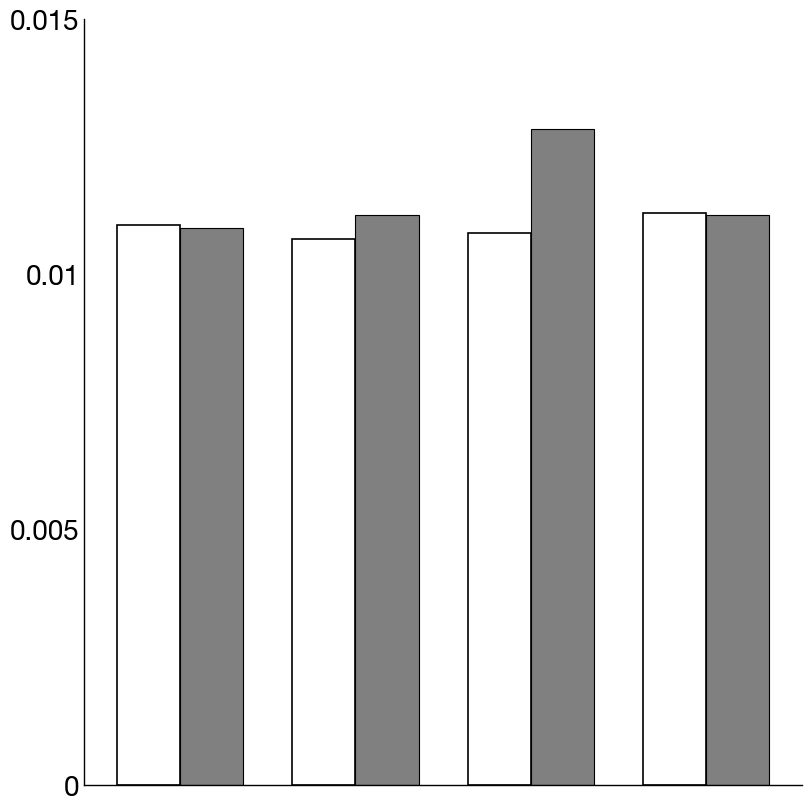

In [108]:
if STUDY == "gastruloid":
    yticks = [0.0, 0.005, 0.01, 0.015]
    ytick_labels = ["0", "0.005", "0.01", "0.015"]
else:
    yticks = [0.0, 0.0005, 0.001]
    ytick_labels = ["0", "0.05", "0.1"]

fig = plot_figure2b_spatial_mse_bars(
    rows,
    yticks=yticks,
    ytick_labels=ytick_labels,
    save_path=f"figures/paper/figure2b_spatial_mse_{STUDY}.png",
)

ae r2=0.577
cae r2=0.778
neuralop r2=0.582
vit r2=0.585


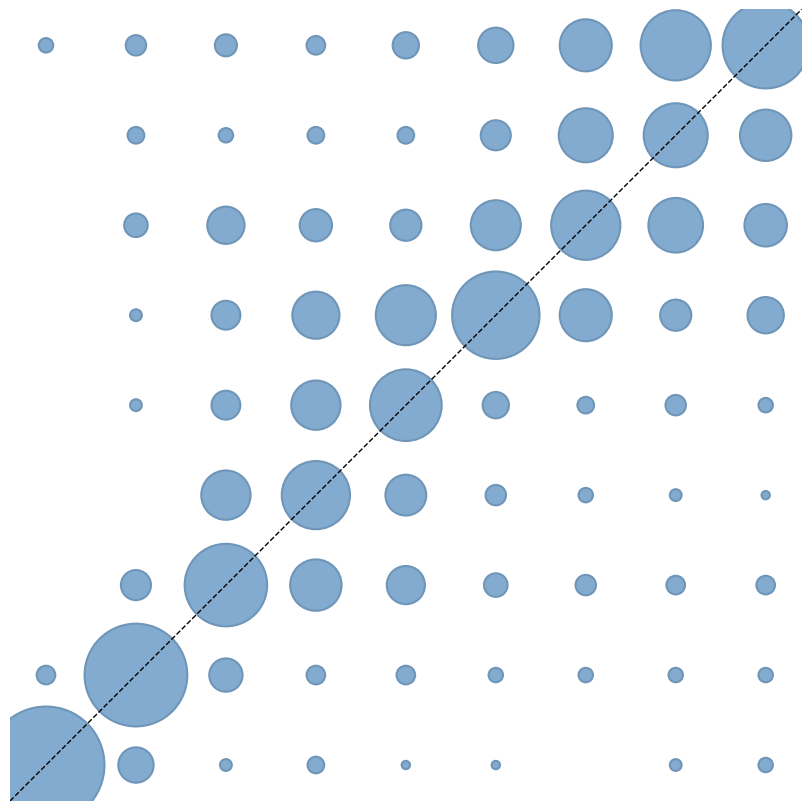

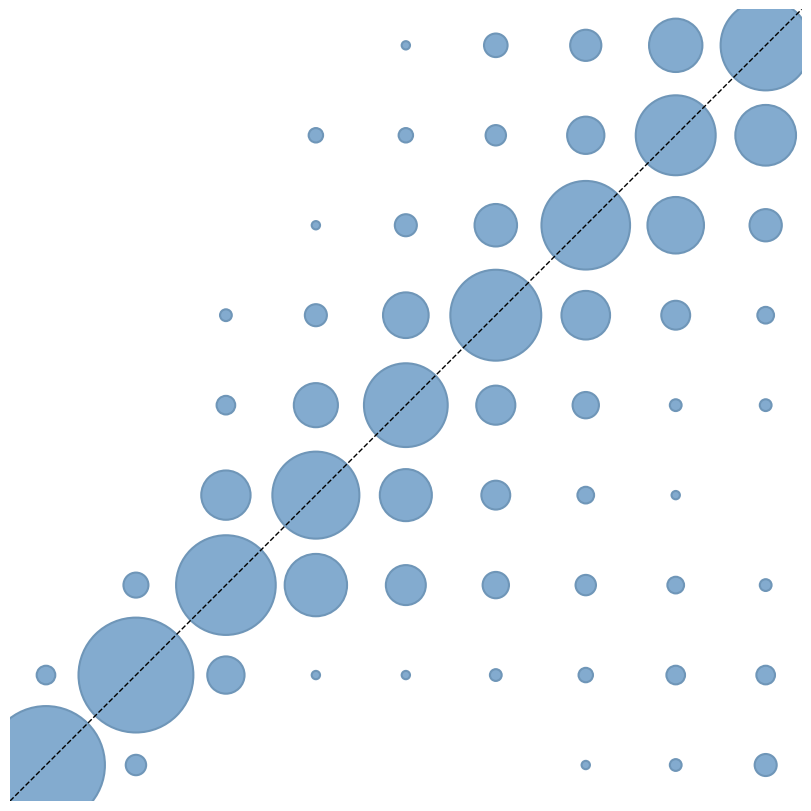

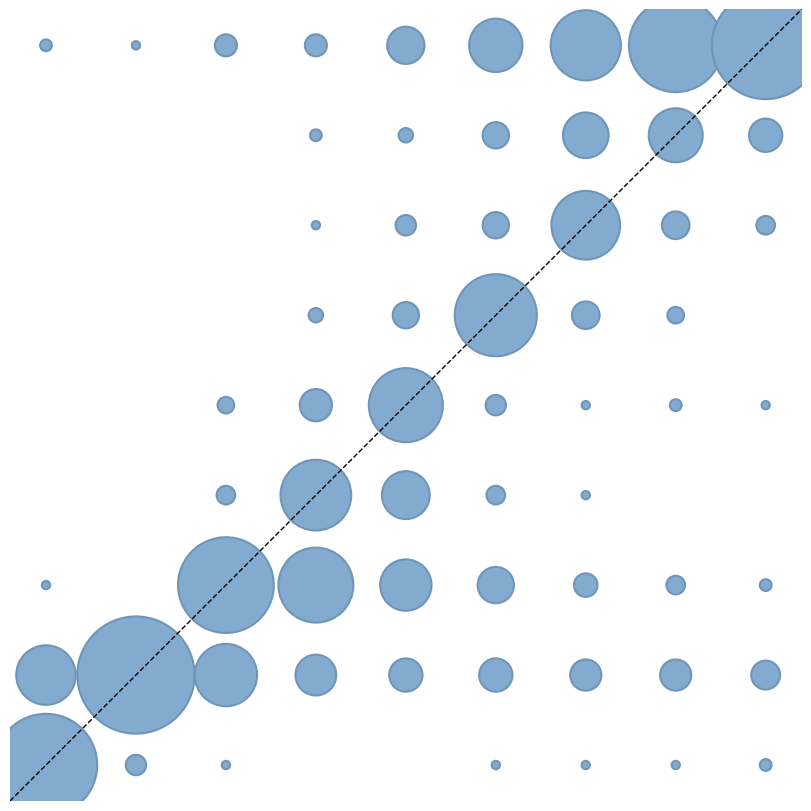

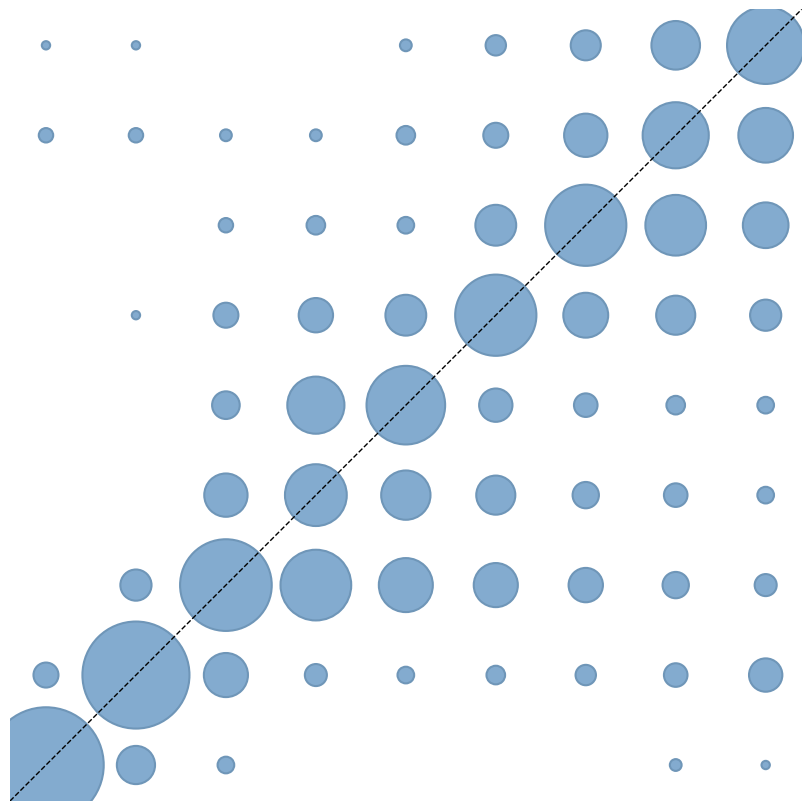

In [109]:
parity = collect_timepoint_parity_data(
    results_dir,
    all_models,
    split="test",
    device="cpu",
)

for model_name in sorted(parity.keys()):
    for dataset_name in sorted(parity[model_name].keys()):
        block = parity[model_name][dataset_name]
        y_true = block["true"]
        y_pred = block["pred"]
        print(f"{model_name} r2={r2_score(y_true, y_pred):.3f}")

        fig, ax = plot_figure2c_timepoint_parity(
            y_true,
            y_pred,
            save_path=f"figures/paper/figure2c_parity_{model_name}_{STUDY}.png",
        )


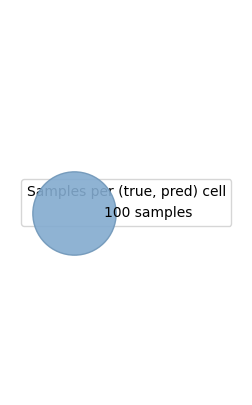

In [110]:
max_cell_count = 0
for model_name in sorted(parity.keys()):
    for dataset_name in sorted(parity[model_name].keys()):
        block = parity[model_name][dataset_name]
        max_cell_count = max(max_cell_count, int(parity_cell_counts(block["true"], block["pred"]).max()))

candidates = [100]
legend_counts = sorted({c for c in candidates if c <= max_cell_count}) or [1]

fig_legend = plot_parity_size_legend(
    legend_counts,
    save_path=f"figures/paper/figure2c_parity_size_legend_{STUDY}.png",
)


### Figure 3

  ae | gastruloid_128 | F1 Euploid = 0.602    F1 Aneuploid = 0.402
  ae | gastruloid_128 | Euploid → Euploid | n=74
  ae | gastruloid_128 | Euploid → Aneuploid | n=26
  ae | gastruloid_128 | Aneuploid → Euploid | n=72
  ae | gastruloid_128 | Aneuploid → Aneuploid | n=33


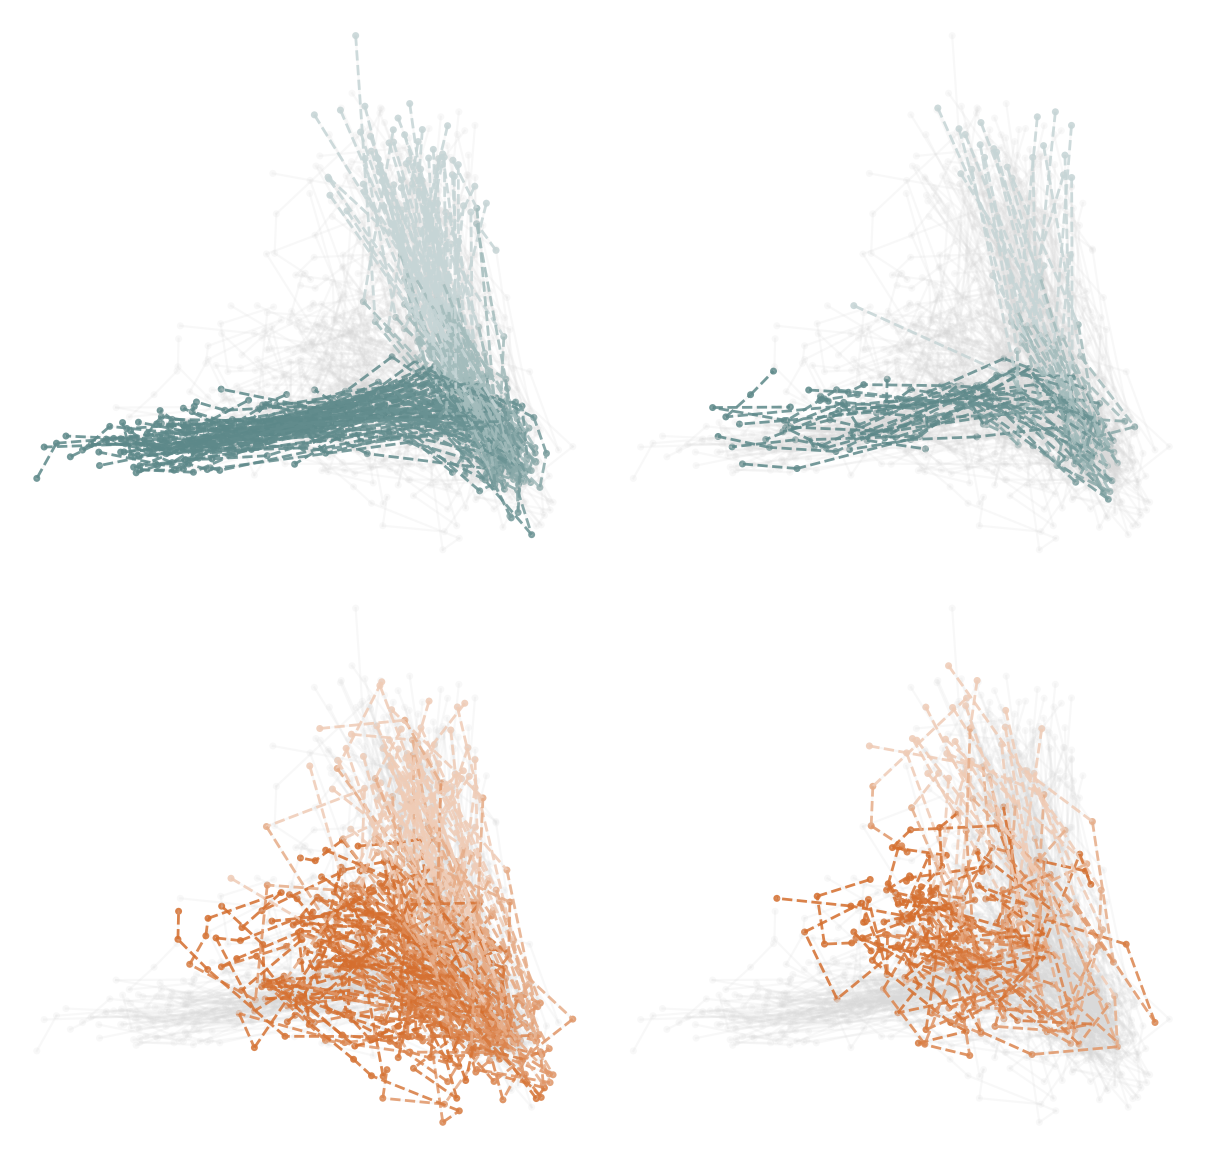

  cae | gastruloid_128 | F1 Euploid = 0.790    F1 Aneuploid = 0.809
  cae | gastruloid_128 | Euploid → Euploid | n=77
  cae | gastruloid_128 | Euploid → Aneuploid | n=28
  cae | gastruloid_128 | Aneuploid → Euploid | n=13
  cae | gastruloid_128 | Aneuploid → Aneuploid | n=87


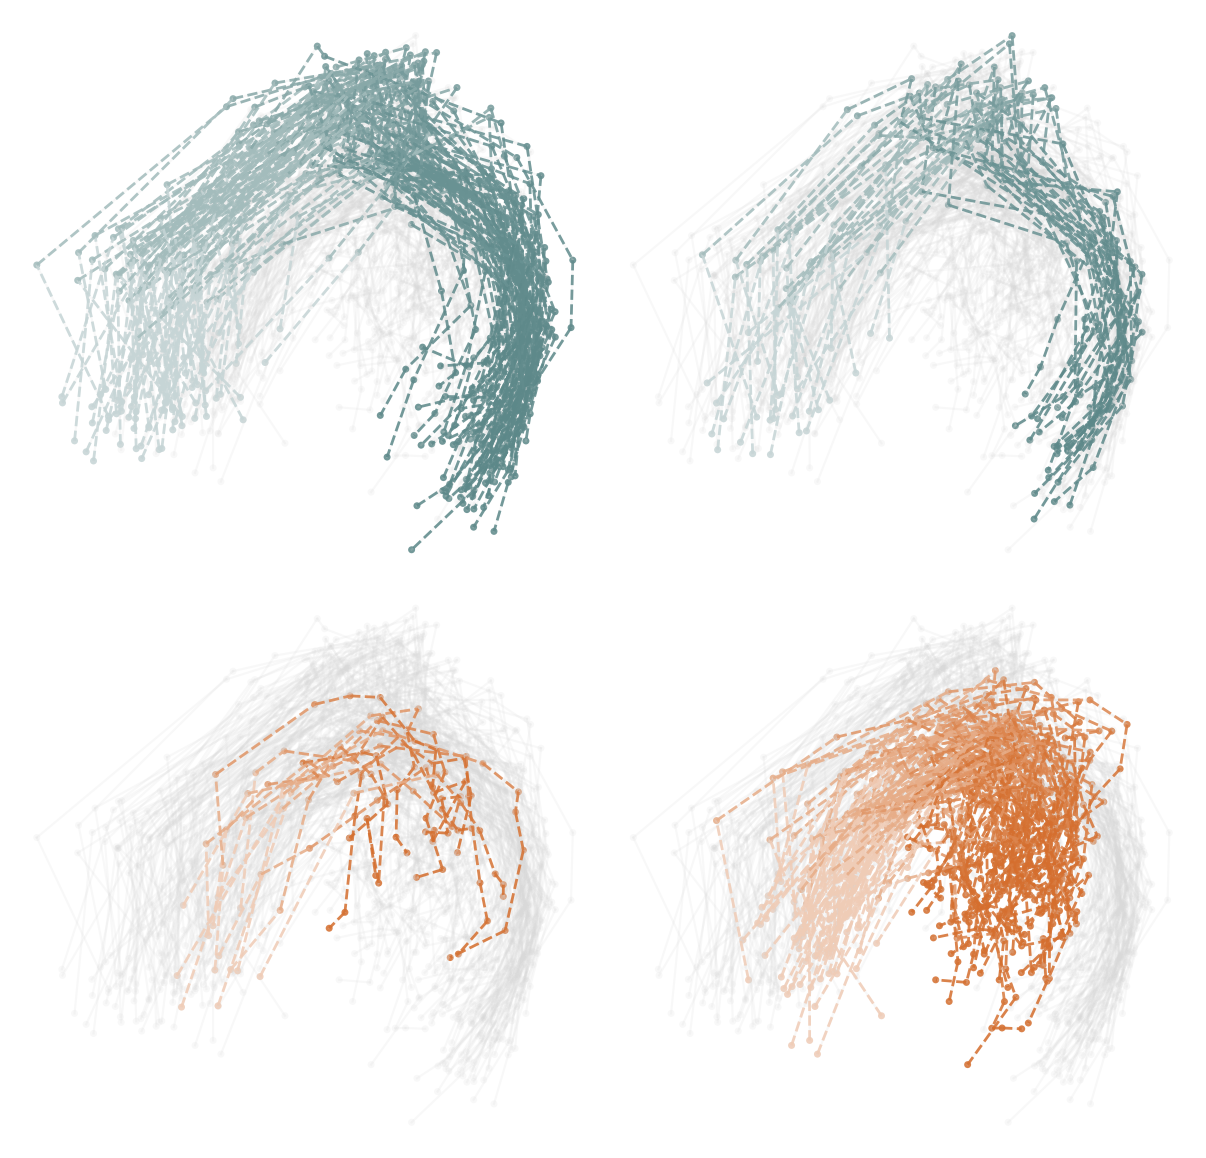

  neuralop | gastruloid_128 | F1 Euploid = 0.797    F1 Aneuploid = 0.679
  neuralop | gastruloid_128 | Euploid → Euploid | n=100
  neuralop | gastruloid_128 | Euploid → Aneuploid | n=5
  neuralop | gastruloid_128 | Aneuploid → Euploid | n=46
  neuralop | gastruloid_128 | Aneuploid → Aneuploid | n=54


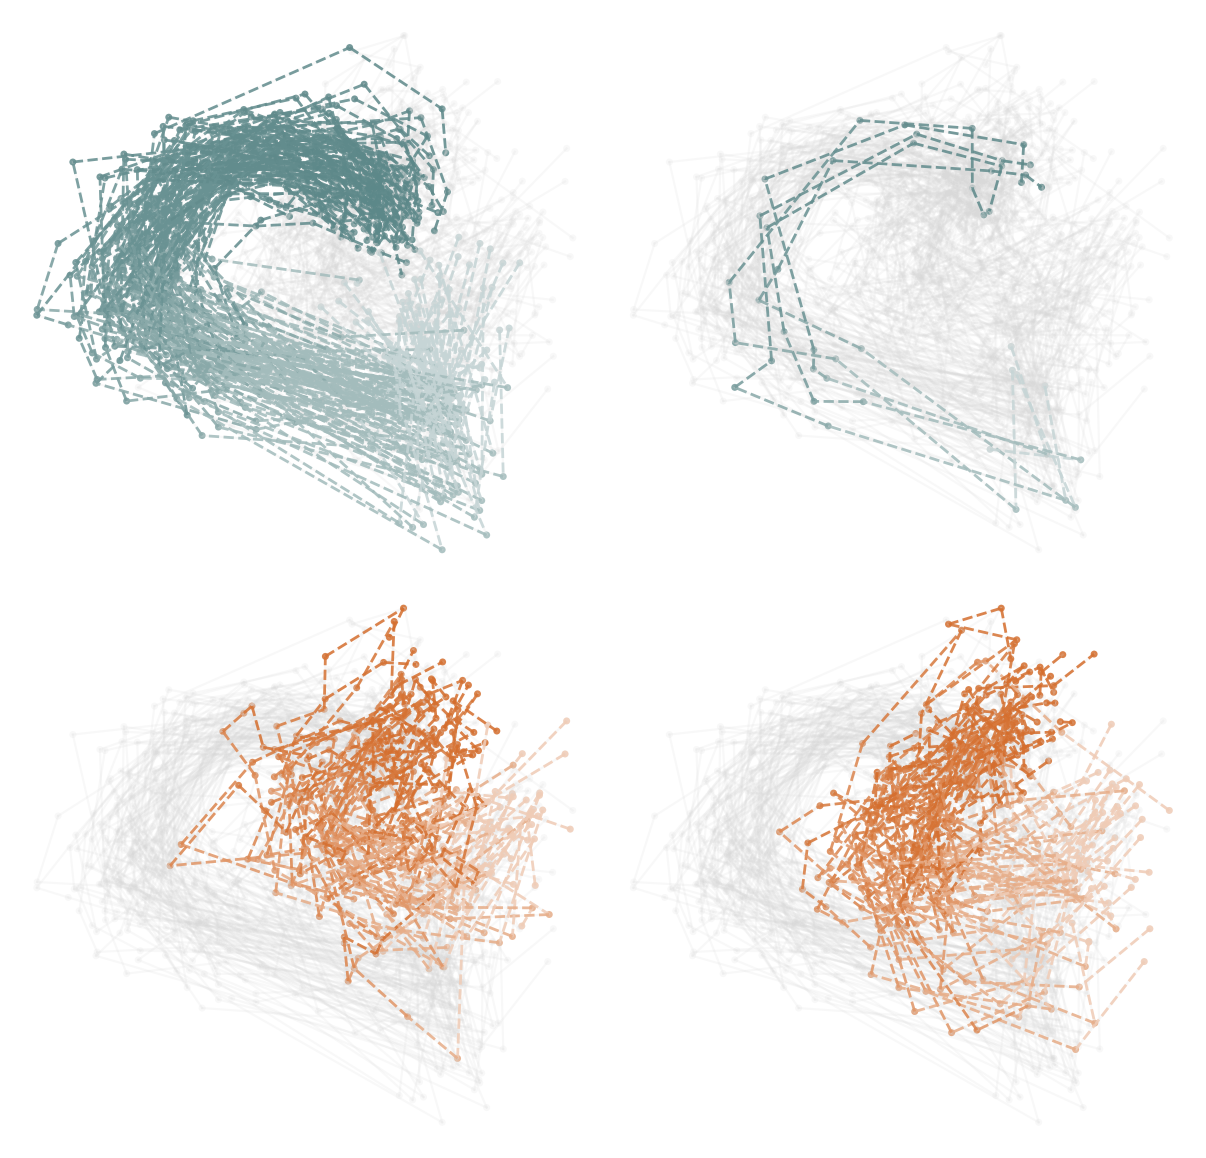

  vit | gastruloid_128 | F1 Euploid = 0.763    F1 Aneuploid = 0.581
  vit | gastruloid_128 | Euploid → Euploid | n=100
  vit | gastruloid_128 | Euploid → Aneuploid | n=0
  vit | gastruloid_128 | Aneuploid → Euploid | n=62
  vit | gastruloid_128 | Aneuploid → Aneuploid | n=43


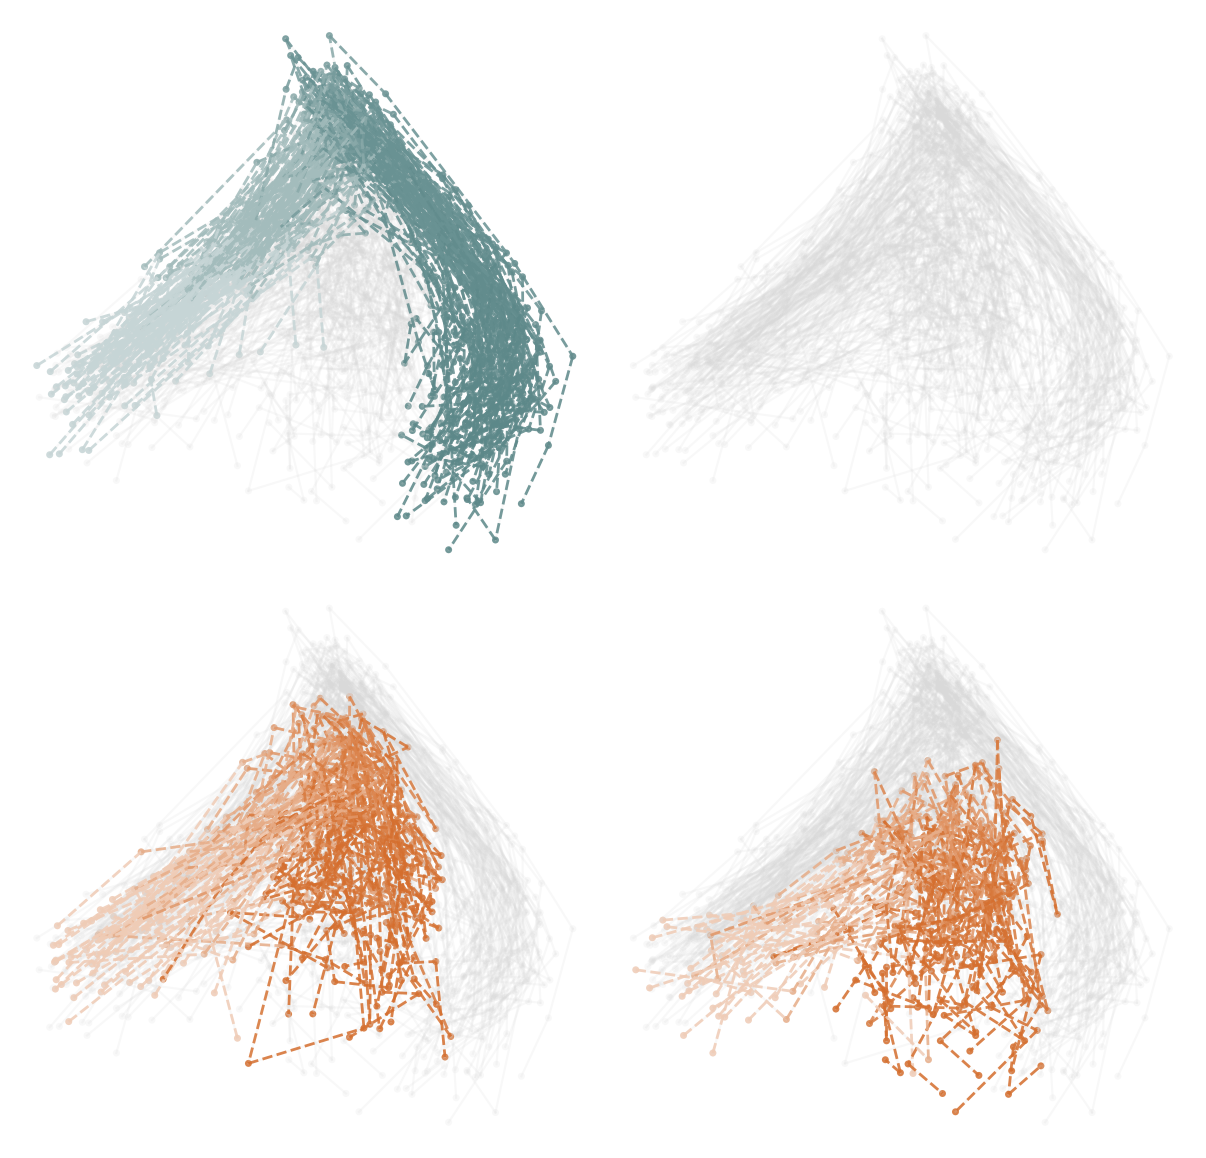

In [111]:
timepoints, sample_ids = load_encoded_metadata(
    results_dir,
    all_models,
    split="test",
)
nn_embeddings = load_encoded_latents(
    results_dir,
    all_models,
    split="test",
    normalize=True,
)

pca_embeddings = {}
for model_name, dataset in nn_embeddings.items():
    pca_embeddings[model_name] = {}
    for dataset_name, embeddings in dataset.items():
        pca = PCA()
        pca_embeddings[model_name][dataset_name] = pca.fit_transform(embeddings)

classification_file = (
    f"results_downstream/classification_results/{c['study_dir']}{c['classification_suffix']}.json"
)
classification_results = json.loads(Path(classification_file).read_text(encoding="utf-8"))
incorrect_samples = defaultdict(lambda: defaultdict(list))
for item in classification_results["model_dataset_results"]:
    mn, dn = item["model_name"], item["dataset_name"]
    incorrect_samples[mn][dn] = item["incorrect_predictions"]

Path("figures").mkdir(exist_ok=True)
Path(f"figures/{c['figures_subdir']}").mkdir(parents=True, exist_ok=True)

for model_name, datasets in all_models.items():
    for dataset_name, _model in datasets.items():
        emb = pca_embeddings[model_name][dataset_name]
        ids = sample_ids[model_name][dataset_name]
        tps = timepoints[model_name][dataset_name]
        incorrect = set(incorrect_samples[model_name][dataset_name])

        if STUDY == "gastruloid":
            y_true_by_sid = {s: (0 if str(s).startswith("array1") else 1) for s in set(ids)}
            class_labels = ("Euploid", "Aneuploid")
            fg_top, fg_bottom = "#5C8889", "#D56E2D"
        else:
            y_true_by_sid = {s: (0 if str(s).startswith("C_") else 1) for s in set(ids)}
            class_labels = ("C", "CH")
            fg_top, fg_bottom = "#C7B862", "#C991B3"

        y_pred_by_sid = {s: (yt if s not in incorrect else 1 - yt) for s, yt in y_true_by_sid.items()}
        uids = sorted(y_true_by_sid.keys())
        yt = np.array([y_true_by_sid[s] for s in uids], dtype=int)
        yp = np.array([y_pred_by_sid[s] for s in uids], dtype=int)
        f1p = f1_score(yt, yp, average=None, labels=[0, 1], zero_division=0)
        print(
            f"  {model_name} | {dataset_name} | F1 {class_labels[0]} = {f1p[0]:.3f}    "
            f"F1 {class_labels[1]} = {f1p[1]:.3f}"
        )

        out = Path(f"figures/{c['figures_subdir']}") / f"{c['figures_subdir']}_{model_name}_confusion_panels.png"
        plot_trajectory_confusion_panels(
            emb,
            ids,
            tps,
            incorrect,
            y_true_by_sid,
            class_labels=class_labels,
            fg_top_color=fg_top,
            fg_bottom_color=fg_bottom,
            log_prefix=f"{model_name} | {dataset_name}",
            save_path=out,
        )
        plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Emergent properties (top → bottom row order):
  1. Mean
  2. Area
  3. XM
  4. YM
  5. Circ.

Test R² (best row per encoder; columns left → right):
  property        ae       cae  neuralop       vit
  ------------------------------------------------
  Mean         0.686     0.686     0.677     0.613
  Area         0.565     0.528     0.539     0.505
  XM           0.421     0.535     0.523     0.366
  YM           0.254     0.100     0.344     0.095
  Circ.        0.603     0.655     0.586     0.431


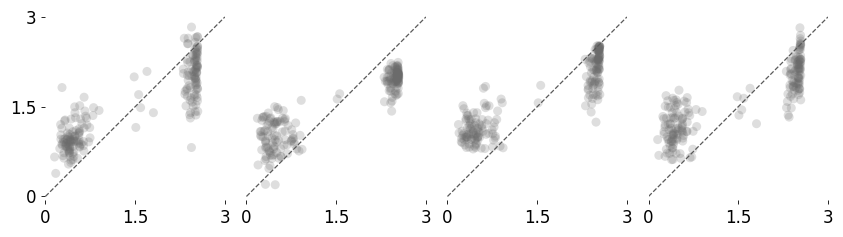

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


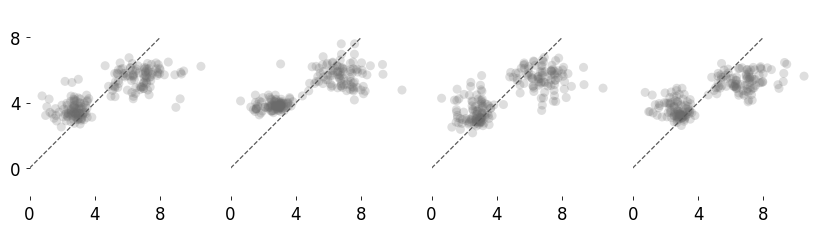

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


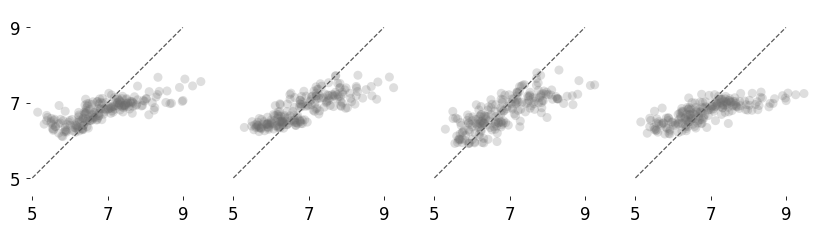

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


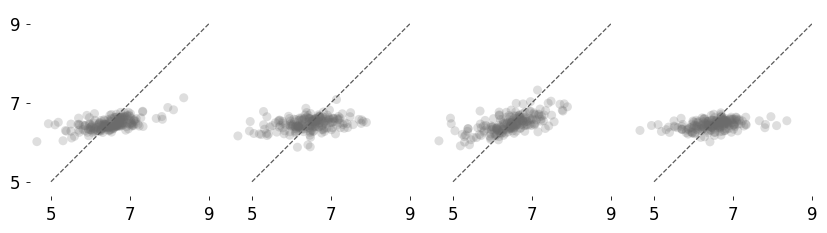

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


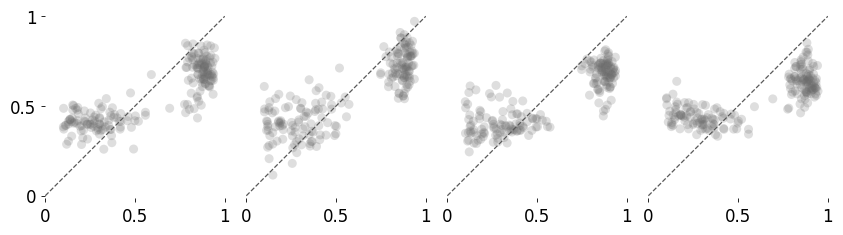

In [112]:
if STUDY == "gastruloid":
    emergent_properties = ["Mean", "Area", "XM", "YM", "Circ."]
    row_ticks: dict[str, dict[str, list[float] | None]] = {
        "Mean": {"x": [0.0, 150, 300], "y": [0.0, 150, 300]},
        "Area": {"x": [0.0, 4000, 8000], "y": [0.0, 4000, 8000]},
        "XM": {"x": [50, 70, 90], "y": [50, 70, 90]},
        "YM": {"x": [50, 70, 90], "y": [50, 70, 90]},
        "Circ.": {"x": [0.0, 0.5, 1.0], "y": [0.0, 0.5, 1.0]},
    }
else:
    emergent_properties = ["VOLUMES", "ACTIVITY", "DIAMETERS", "GROWTH", "SYMMETRY", "COUNTS"]
    row_ticks = {
        "VOLUMES": {"x": [200000, 900000, 1600000], "y": [200000,900000, 1600000]},
        "ACTIVITY": {"x": [-0.5, 0.0, 0.5, 1.0], "y": [-0.5, 0.0, 0.5, 1.0]},
        "DIAMETERS": {"x": [5, 15, 25], "y": [5, 15, 25]},
        "GROWTH": {"x": [0.0, 0.75, 1.5], "y": [0.0, 0.75, 1.5]},
        "SYMMETRY": {"x": [0.25, 0.5, 0.75], "y": [0.25, 0.5, 0.75]},
        "COUNTS": {"x": [0, 200, 400], "y": [0, 200, 400]},
    }

RESULTS_DIR = Path("results_downstream") / "classification_results"
_payloads = [load_point_regression_json(RESULTS_DIR, p) for p in emergent_properties]
_model_order = sorted(
    {str(r["model_name"]) for pl in _payloads for r in pl["model_dataset_results"]}
)

print_emergent_parity_legend(emergent_properties, _payloads, _model_order)
for prop, pl in zip(emergent_properties, _payloads):
    plot_emergent_parity_row(
        prop,
        pl,
        models=_model_order,
        row_ticks=row_ticks,
        tick_labelsize=12,
    )
    plt.show()
